# Optimal integration comparison

Generate `optimal_integration_comparison.pdf` and the matching manuscript asset from the real bimodal psychometric fits and unimodal auditory/visual fits.

In [5]:
from pathlib import Path
import os

ROOT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str((ROOT / ".matplotlib_cache").resolve()))

import json
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

from plot_style import *

FIG_DIR = ROOT / "ms_latex" / "assets" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATHS = [
    ROOT / "optimal_integration_comparison.pdf",
    ROOT / "optimal_integration_comparison.png",
    FIG_DIR / "optimal_integration_comparison.pdf",
    FIG_DIR / "optimal_integration_comparison.png",
]

MODEL_NOISE_OUT_PATHS = [
    ROOT / "optimal_integration_model_noise_comparison.pdf",
    ROOT / "optimal_integration_model_noise_comparison.png",
    FIG_DIR / "optimal_integration_model_noise_comparison.pdf",
    FIG_DIR / "optimal_integration_model_noise_comparison.png",
]

HIGH_NOISE = 1.2
LOW_NOISE = 0.1

MODEL_STYLE = {
    "fusionOnlyLogNorm": {"label": "Forced fusion", "color": "#2ca02c", "marker": "s"},
    "lognorm": {"label": "Causal inference", "color": "#600c70", "marker": "o"},
    "switchingFree": {"label": "Cue switching", "color": "#080529", "marker": "^"},
}
MODEL_ORDER = ["fusionOnlyLogNorm", "lognorm", "switchingFree"]

## Load complete participants

The old `plotAllModelFits.ipynb` tried to include `all` and `ln1`; those do not have all of the required unimodal `.mat` files. This notebook keeps only participants with a real bimodal psychometric fit, unimodal auditory fit, unimodal visual fit, and `*_all.csv` data file.

In [6]:
def complete_participants():
    participants = []
    for fit_path in sorted((ROOT / "psychometric_fits_real").glob("*/*_psychometricFits.json")):
        pid = fit_path.parent.name
        if pid == "all":
            continue

        required = [
            ROOT / "data" / f"{pid}_all.csv",
            ROOT / "data" / f"{pid}_auditory_fits.mat",
            ROOT / "data" / f"{pid}_visual_fits.mat",
            ROOT / "psychometric_fits_real" / pid / f"{pid}_psychometricFits.json",
        ]
        if all(path.exists() for path in required):
            participants.append(pid)
        else:
            missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
            print(f"Skipping {pid}: missing {missing}")
    return participants


participant_ids = complete_participants()
participant_ids

Skipping ln1: missing ['data/ln1_auditory_fits.mat', 'data/ln1_visual_fits.mat']


['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']

## Compute predicted and observed variability

`sigma_opt` is the reliability-weighted optimal prediction from unimodal auditory and visual variability. `sigma_AV` is the observed bimodal psychometric variability from the real bimodal task fits.

In [7]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def bimodal_sigma_av(pid, noise_level):
    fit_path = ROOT / "psychometric_fits_real" / pid / f"{pid}_psychometricFits.json"
    data_path = ROOT / "data" / f"{pid}_all.csv"

    fit_params = np.asarray(load_json(fit_path)["fitParams"], dtype=float)
    data = pd.read_csv(data_path)
    unique_noise = data["audNoise"].dropna().drop_duplicates().to_numpy(dtype=float)

    noise_idx = np.where(np.isclose(unique_noise, noise_level))[0]
    if len(noise_idx) == 0:
        raise ValueError(f"{pid}: noise level {noise_level} not found in {unique_noise}")

    # Psychometric fits use: [lambda_1, lambda_2, lambda_3, sigma_noise_1, ...]
    return fit_params[3 + int(noise_idx[0])]


def optimal_sigma(sigma_a, sigma_v):
    return 1.0 / np.sqrt(1.0 / sigma_a**2 + 1.0 / sigma_v**2)


rows = []
for pid in participant_ids:
    auditory = scipy.io.loadmat(ROOT / "data" / f"{pid}_auditory_fits.mat")["fittedParams"].flatten()
    visual = scipy.io.loadmat(ROOT / "data" / f"{pid}_visual_fits.mat")["fittedParams"].flatten()

    # Same indexing as the original plotAllModelFits.ipynb cell.
    sigma_a_high = float(auditory[1])
    sigma_a_low = float(auditory[2])
    sigma_v = float(visual[1])

    rows.append({
        "participant": pid,
        "sigma_opt_high": optimal_sigma(sigma_a_high, sigma_v),
        "sigma_av_high": bimodal_sigma_av(pid, HIGH_NOISE),
        "sigma_opt_low": optimal_sigma(sigma_a_low, sigma_v),
        "sigma_av_low": bimodal_sigma_av(pid, LOW_NOISE),
        "sigma_a_high": sigma_a_high,
        "sigma_a_low": sigma_a_low,
        "sigma_v": sigma_v,
    })

df_opt = pd.DataFrame(rows)
df_opt

,participant,sigma_opt_high,sigma_av_high,sigma_opt_low,sigma_av_low,sigma_a_high,sigma_a_low,sigma_v
0,as,1.121644,0.302350,0.233736,0.168996,3.500000,0.238427,1.184095
1,dt,0.691150,0.234254,0.303273,0.133873,2.222826,0.333675,0.727195
2,hh,0.491806,0.142131,0.009998,0.074853,2.130812,0.010000,0.505453
3,ip,0.331504,0.370451,0.288345,0.178136,0.521551,0.389126,0.429405
4,ln2,0.735016,0.131939,0.238134,0.280371,2.724685,0.250643,0.763314
5,mh,0.358282,0.321798,0.261545,0.295366,1.124372,0.362275,0.377985
6,ml,0.505970,0.239595,0.313105,0.216625,1.877348,0.389898,0.525412
7,mt,0.501338,0.213539,0.216108,0.104524,3.500000,0.238943,0.506562
8,oy,0.475555,0.267799,0.232213,0.198268,0.505136,0.235426,1.410379
9,qs,0.292646,0.354041,0.216204,0.154069,0.375843,0.244006,0.466389


## Plot observed bimodal noise and export

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
colors = plt.get_cmap("tab20", len(df_opt))

panels = [
    ("High auditory noise", "sigma_opt_high", "sigma_av_high"),
    ("Low auditory noise", "sigma_opt_low", "sigma_av_low"),
]

all_values = np.r_[
    df_opt["sigma_opt_high"], df_opt["sigma_av_high"],
    df_opt["sigma_opt_low"], df_opt["sigma_av_low"],
]
plot_min = max(0, float(np.nanmin(all_values)) - 0.05)
plot_max = float(np.nanmax(all_values)) + 0.08

for ax, (title, x_col, y_col) in zip(axes, panels):
    for idx, row in df_opt.iterrows():
        ax.scatter(
            row[x_col], row[y_col],
            s=115,
            color=colors(idx),
            edgecolors="black",
            linewidths=1.2,
            alpha=0.88,
            zorder=3,
        )

    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black", lw=1.7, alpha=0.65, zorder=1)
    ax.set_title(title, pad=12)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", which="major")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

add_panel_labels(axes, x=-0.14, y=1.08)
fig.supxlabel(r"Fusion predicted noise: $\sigma_{\mathrm{opt}}$", y=-0.02, fontsize=FONT_SIZE_LABEL)
fig.supylabel(r"Bimodal experiment task noise: $\sigma_{AV}$", x=-0.02, fontsize=FONT_SIZE_LABEL)

for out_path in OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()

Saved optimal_integration_comparison.pdf
Saved optimal_integration_comparison.png
Saved ms_latex/assets/figures/optimal_integration_comparison.pdf


## Compare free-fitted model noise with optimal-fusion prediction

This companion figure uses the free psychometric refits of each model's simulated responses. For each participant, model, and auditory-noise condition, `sigma_plot` is averaged across conflict levels and plotted against the participant's optimal-fusion prediction from unimodal noise estimates.

In [14]:
def load_free_model_noise(pid, model_name):
    path = ROOT / "psychometric_fits_freeMuSigmaLambda_simulated" / pid / f"{pid}_{model_name}_psychometricFits.json"
    if not path.exists():
        print(f"Missing {path.relative_to(ROOT)}")
        return pd.DataFrame()

    payload = load_json(path)
    df = pd.DataFrame(payload["fitParamsByCondition"])
    df["participant"] = pid
    df["model"] = model_name
    return df


model_noise = pd.concat(
    [load_free_model_noise(pid, model) for pid in participant_ids for model in MODEL_ORDER],
    ignore_index=True,
)

model_noise_summary = (
    model_noise
    .groupby(["participant", "model", "audioNoise"], as_index=False)
    .agg(model_sigma=("sigma_plot", "mean"), n_conflicts=("conflict", "nunique"))
)

opt_long = pd.concat([
    df_opt[["participant", "sigma_opt_high"]].rename(columns={"sigma_opt_high": "sigma_opt"}).assign(audioNoise=HIGH_NOISE),
    df_opt[["participant", "sigma_opt_low"]].rename(columns={"sigma_opt_low": "sigma_opt"}).assign(audioNoise=LOW_NOISE),
], ignore_index=True)

model_noise_summary = model_noise_summary.merge(opt_long, on=["participant", "audioNoise"], how="left")
model_noise_summary

,participant,model,audioNoise,model_sigma,n_conflicts,sigma_opt
0,as,fusionOnlyLogNorm,0.1,0.335367,7,0.233736
1,as,fusionOnlyLogNorm,1.2,0.555538,7,1.121644
2,as,lognorm,0.1,0.291618,7,0.233736
3,as,lognorm,1.2,0.575040,7,1.121644
4,as,switchingFree,0.1,0.309881,7,0.233736
...,...,...,...,...,...,...
61,sx,fusionOnlyLogNorm,1.2,0.455811,7,0.435862
62,sx,lognorm,0.1,0.354374,7,0.228680
63,sx,lognorm,1.2,0.428867,7,0.435862
64,sx,switchingFree,0.1,0.339178,7,0.228680


Saved optimal_integration_model_noise_comparison.pdf
Saved optimal_integration_model_noise_comparison.png
Saved ms_latex/assets/figures/optimal_integration_model_noise_comparison.pdf
Saved ms_latex/assets/figures/optimal_integration_model_noise_comparison.png


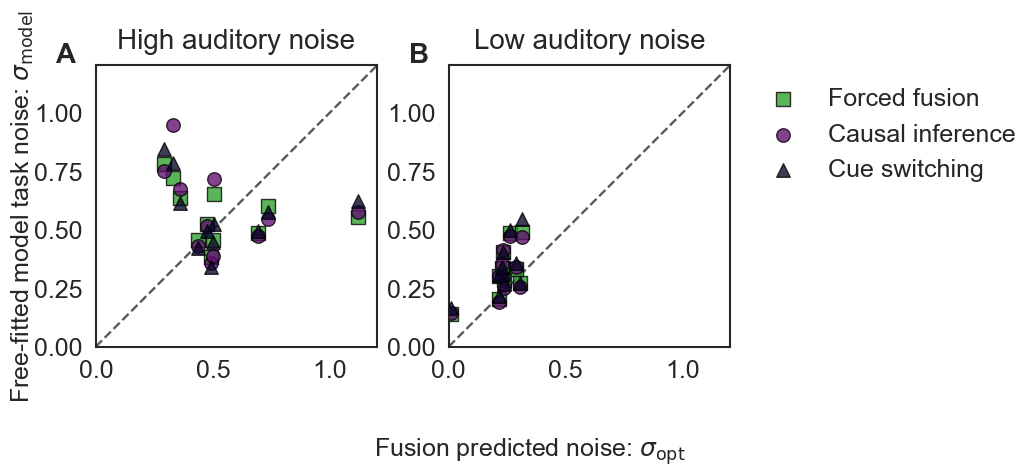

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
noise_panels = [(HIGH_NOISE, "High auditory noise"), (LOW_NOISE, "Low auditory noise")]

all_values = np.r_[model_noise_summary["sigma_opt"], model_noise_summary["model_sigma"]]
plot_min = max(0, float(np.nanmin(all_values)) - 0.05)
plot_max = float(np.nanmax(all_values)) + 0.08

for ax, (noise, title) in zip(axes, noise_panels):
    sub_noise = model_noise_summary[np.isclose(model_noise_summary["audioNoise"], noise)]
    for model_name in MODEL_ORDER:
        style = MODEL_STYLE[model_name]
        sub = sub_noise[sub_noise["model"] == model_name]
        ax.scatter(
            sub["sigma_opt"], sub["model_sigma"],
            s=95,
            color=style["color"],
            marker=style["marker"],
            edgecolors="black",
            linewidths=1.0,
            alpha=0.78,
            label=style["label"],
            zorder=3,
        )

    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black", lw=1.7, alpha=0.65, zorder=1)
    ax.set_title(title, pad=12)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

add_panel_labels(axes, x=-0.14, y=1.08)
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.supxlabel(r"Fusion predicted noise: $\sigma_{\mathrm{opt}}$", y=-0.02, fontsize=FONT_SIZE_LABEL)
fig.supylabel(r"Free-fitted model task noise: $\sigma_{\mathrm{model}}$", x=-0.02, fontsize=FONT_SIZE_LABEL)

for out_path in MODEL_NOISE_OUT_PATHS:
    fig.savefig(out_path, dpi=400, bbox_inches="tight")
    print(f"Saved {out_path.relative_to(ROOT)}")

plt.show()